<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Installing Dependencies
</h2>
</div>

In [1]:
# !pip install -U peft bitsandbytes transformers accelerate

In [2]:
# !pip install -q \
# transformers==4.56.1 \
# trl==0.22.2 \
# peft==0.17.1 \
# accelerate==1.10.1

In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

CUDA available: True
GPU: Tesla T4
GPU count: 2


In [5]:
pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.6 MB/s eta 0:00:00:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
Note: you may need to restart the kernel to use updated packages.


In [6]:
from datasets import load_dataset

# Load only the train split
dataset = load_dataset(
    "AnmolNimmala0/agri-slm-corpus",
    split="train"
)

# Randomly select 20k examples
dataset = dataset.shuffle(seed=42).select(range(10000))

print(dataset)

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


corpus_filtered.jsonl:   0%|          | 0.00/6.84G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['text', 'source', 'domain', 'subdomain', 'language', 'word_count', 'url', 'title', 'year', 'journal', 'crop', 'state'],
    num_rows: 10000
})


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Non Instuction Fine-Tuned Model Loading
</h2>
</div>

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch


BASE_MODEL = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

ADAPTER_PATH = "/kaggle/input/models/offcialdeepak/non-instruction-finetuning/pytorch/default/1/checkpoint-6250"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)


non_instruction_model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH
)


non_instruction_model.eval()

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [8]:
print(dataset[2]["text"])

Value Engineering Approach to Evaluate the Agricultural Drainage Water Management Strategies

Excessive irrigating water that has not been adequately drained may cause more water to enter the crop root zone than is necessary. As a result, issues with increasing water table levels, waterlogging, and salinity get worse and cause crop productivity losses. Agricultural drainage water management strategies (ADWMS) can be used to protect the quality of groundwater, guarantee that crops have better moisture conditions, and provide irrigation water by reusing agricultural water drainage and using sub-irrigation practices. In order to decrease the effects of poor drainage, mitigate climate change, conserve the environment, and achieve food security, this study proposes a framework for choosing the most effective ADWMS in Egypt&rsquo;s Nile Delta as well as the new lands. The value engineering approach is used to ensure the strategy&rsquo;s functionality and to present some innovation in the pro

#### Response Generation from Non Instruction Fine-Tuned Model

In [9]:
prompt = """Value Engineering Approach to Evaluate the Agricultural Drainage Water Management Strategies
"""

In [10]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(non_instruction_model.device)


outputs = non_instruction_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1
)


print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Value Engineering Approach to Evaluate the Agricultural Drainage Water Management Strategies

Water management in agriculture has been an important issue for many years. The water management practices are increasingly being recognized as a key element in ensuring food security and sustainable development. Agricultural drainage water is one of the most critical components in irrigation systems. However, it is often overlooked when designing or maintaining drainage systems due to its poor understanding. This study examines the impact of different water management strategies on agricultural drain


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
    Instruction Fine Tuning
</h2>
</div>

In [11]:
from datasets import load_dataset

# Load only the train split
dataset = load_dataset(
    "KisanVaani/agriculture-qa-english-only",
    split="train"
)

# Randomly select 20k examples
dataset = dataset.shuffle(seed=42).select(range(15000))

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.97M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/22615 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answers'],
    num_rows: 15000
})


In [12]:
from datasets import load_dataset
dataset = load_dataset("KisanVaani/agriculture-qa-english-only", split="train")

In [13]:
dataset

Dataset({
    features: ['question', 'answers'],
    num_rows: 22615
})

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
    📝 Formatting the Dataset for Instruction Fine-Tuning
</h2>
</div>

In [14]:
def format_row(example):
    question = example["question"]
    answer = example["answers"]
    example["Text"] = f"[Context] {question} [/Response] {answer}"
    return example

In [15]:
formatted_dataset = dataset.map(format_row)

Map:   0%|          | 0/22615 [00:00<?, ? examples/s]

In [16]:
print(formatted_dataset[0]["Text"])

[Context] why is crop rotation important in farming? [/Response] This helps to prevent soil erosion and depletion, and can also help to control pests and diseases


In [17]:
import pandas as pd

# Convert dataset to DataFrame
df = pd.DataFrame(dataset)

In [18]:
df

,question,answers
0,why is crop rotation important in farming?,This helps to prevent soil erosion and depleti...
1,What farming practice helps prevent soil erosion?,Crop Rotation
2,what is crop rotation,Crop rotation is the practice of growing a ser...
3,what are the different methods of irrigation?,"surface irrigation, drip irrigation, and sprin..."
4,why is soil health vital?,Soil health is critical to crop growth and pro...
...,...,...
22610,Does cassava mosaic affect the cassava stems?,"Yes, it makes them small and not good for plan..."
22611,How does the pathogen of Phoma Rot spread?,The pathogen of Phoma Rot is seed-borne.
22612,Does cassava have much sugar in it when testing?,"Yes, but not as much as sugar cane"
22613,Can the chemical used for storing affect seed ...,"No, it does not affect germination"


In [19]:
df.to_csv("KisanVaani-agriculture-qa-english-only.csv", index=False)

In [20]:
df.to_json("KisanVaani-agriculture-qa-english-onlyjsonl", orient="records", lines=True)

In [21]:
from datasets import load_dataset

dataset = load_dataset("csv", data_files="KisanVaani-agriculture-qa-english-only.csv",split="train")
dataset


Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['question', 'answers'],
    num_rows: 22615
})

In [22]:
def format_example(example):
    prompt = f"### Input:\n{example['question']}\n### Response:\n{example['answers']}"
    return {"text": prompt}

In [23]:
dataset = dataset.map(format_example)

Map:   0%|          | 0/22615 [00:00<?, ? examples/s]

In [24]:
dataset

Dataset({
    features: ['question', 'answers', 'text'],
    num_rows: 22615
})

In [25]:
dataset['text'][0]

'### Input:\nwhy is crop rotation important in farming?\n### Response:\nThis helps to prevent soil erosion and depletion, and can also help to control pests and diseases'

In [26]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

#### Tokenizing the Instruction Fine-Tuning Dataset

In [27]:
def tokenize_fn(example):
    tokens = tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

In [28]:
tokenized = dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/22615 [00:00<?, ? examples/s]

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Setting Up Parameter-Efficient Fine-Tuning (LoRA) Configuration
</h2>
</div>

In [29]:
from peft import LoraConfig, get_peft_model, TaskType

In [30]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none"
)

#### Loading the Non Instruction Fine-Tuned Model

In [33]:
non_instruction_adapter = "/kaggle/input/models/offcialdeepak/non-instruction-finetuning/pytorch/default/1/kaggle/working/tinyllama-aggriculture-domain-lora/checkpoint-6250"

In [34]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)

# non_instruction_model = PeftModel.from_pretrained(
#     base_model,
#     '/kaggle/input/models/offcialdeepak/none-instruction/pytorch/default/1/checkpoint-6250'
# )

# Load DAPT / non-instruction LoRA
non_instruction_model = PeftModel.from_pretrained(
    base_model,
    non_instruction_adapter
)


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

#### Merging Base model weights with Non Instruction(LORA) Weights

In [35]:
# Merge LoRA weights into base model
non_instruction_model = non_instruction_model.merge_and_unload()

# Now attach NEW LoRA for instruction fine-tuning
instruction_model = get_peft_model(
    non_instruction_model,
    lora_config
)

In [36]:
instruction_model.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [39]:
# !pip install trl==0.22.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.8/544.8 kB 12.0 MB/s eta 0:00:0000:01


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Training Configuration Agriculture Domain Instruction Fine-Tuning
</h2>
</div>

In [41]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./tinyllama-aggriculture-domain-instruction-finetuned",
    num_train_epochs=2,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_total_limit=1,
    report_to="none"
)


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
    Initializing Trainer for Instruction Fine-Tuning
</h2>
</div>

In [43]:
from transformers import Trainer
trainer = Trainer(
    model=instruction_model,
    args=args,
    train_dataset=tokenized,
)

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Training the Instruction Fine-Tuning Model
</h2>
</div>

In [44]:
trainer.train()

Step,Training Loss
20,0.392580
40,0.201673
60,0.204127
80,0.187610
100,0.173002
120,0.190876
140,0.186175
160,0.191995
180,0.196085
200,0.170073


TrainOutput(global_step=5654, training_loss=0.10240591909086742, metrics={'train_runtime': 7927.0159, 'train_samples_per_second': 5.706, 'train_steps_per_second': 0.713, 'total_flos': 1.4389844643938304e+17, 'train_loss': 0.10240591909086742, 'epoch': 2.0})

In [45]:

trainer.save_model("./tinyllama-aggriculture-domain-instruction-finetuned")
tokenizer.save_pretrained("./tinyllama-aggriculture-domain-instruction-finetuned")

('./tinyllama-aggriculture-domain-instruction-finetuned/tokenizer_config.json',
 './tinyllama-aggriculture-domain-instruction-finetuned/chat_template.jinja',
 './tinyllama-aggriculture-domain-instruction-finetuned/tokenizer.json')

In [46]:
import shutil

shutil.make_archive(
    "tinyllama-aggriculture-domain-instruction-finetuned",
    "zip",
    "./tinyllama-aggriculture-domain-instruction-finetuned"
)

'/kaggle/working/tinyllama-aggriculture-domain-instruction-finetuned.zip'

#### Loading Instruction Fine-Tuned Model

In [47]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)
model = PeftModel.from_pretrained(
    base_model,
    "/kaggle/working/tinyllama-aggriculture-domain-instruction-finetuned"
)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [52]:
instruction_model_path = model

In [53]:
instruction_model_path

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [54]:
dataset[5]

{'question': 'what are the causes of soil degradation?',
 'answers': 'erosion, compaction, and nutrient depletion',
 'text': '### Input:\nwhat are the causes of soil degradation?\n### Response:\nerosion, compaction, and nutrient depletion'}

In [55]:
dataset[111]

{'question': 'what is soil fertility',
 'answers': 'Soil fertility is the ability of soil to sustain plant growth and optimize crop yield',
 'text': '### Input:\nwhat is soil fertility\n### Response:\nSoil fertility is the ability of soil to sustain plant growth and optimize crop yield'}

#### Response Generation prompt by Instruction Fine-Tuned Model

In [58]:
prompt = """### Input:
what is soil fertility?

### Response:
"""

In [59]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(instruction_model.device)

outputs = instruction_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Input:
what is soil fertility?

### Response:
Soil fertility refers to the amount and quality of nutrients available to plants for growth and nutrient uptake. Soil organisms can break down this nitrogen, phosphorus, and other elements into a usable form for plant use.

2. Nutrient availability
3. Microbial activity
4. Water
5. Light
6. Temperature
7. Concentration
8. PH
9


In [64]:
dataset[15]

{'question': 'what are organic fertilizers?',
 'answers': 'organic fertilizers, which are made from natural materials such as manure and compost',
 'text': '### Input:\nwhat are organic fertilizers?\n### Response:\norganic fertilizers, which are made from natural materials such as manure and compost'}

In [66]:
prompt = """### Input:
what are organic fertilizers?

### Response:
"""

In [68]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(instruction_model.device)

outputs = instruction_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Input:
what are organic fertilizers?

### Response:
an ingredient in some organic farming practices that is made from organic matter and added to soil to improve it over time through better plant growth 



In [69]:
dataset[57]

{'question': 'What are some common pests and diseases that can affect beans, and how can they be managed?',
 'answers': 'Common pests include aphids, thrips, and spider mites, while diseases such as bacterial blight and rust can also affect the crop. Pest and disease management typically involves the use of chemical or organic pesticides and fungicides, as well as proper crop rotation to reduce the risk of infection',
 'text': '### Input:\nWhat are some common pests and diseases that can affect beans, and how can they be managed?\n### Response:\nCommon pests include aphids, thrips, and spider mites, while diseases such as bacterial blight and rust can also affect the crop. Pest and disease management typically involves the use of chemical or organic pesticides and fungicides, as well as proper crop rotation to reduce the risk of infection'}

In [70]:
prompt = """### Input:
What are some common pests and diseases that can affect beans, and how can they be managed?

### Response:
"""

In [71]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(instruction_model.device)

outputs = instruction_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Input:
What are some common pests and diseases that can affect beans, and how can they be managed?

### Response:
Corn has a higher risk of pest and disease problems than beans. Beans have been known to be affected by bean moths, aphids, thrips, and spider mites. Pests such as bean looper and bean weevil can also cause significant damage to the crop. Diseases such as bean rust and downy mildew can also affect the crop.


In [83]:
dataset[20345]

{'question': 'How can a farmer control bean weevil in the store?',
 'answers': 'Cleaning and hygiene: Before storing beans, ensure that the storage area is clean and free from debris and residues that may harbor pests. Thoroughly clean the storage containers or structures to remove any existing infestations.\n\nProper storage containers: Use airtight containers, such as metal or plastic bins with tight-fitting lids, to store beans. This helps prevent weevils from entering and infesting the beans. Avoid using jute bags or other porous materials that can allow pest entry.\n\nTemperature control: Weevils thrive in warm temperatures. Keeping the storage area cool can help deter their growth and reproduction. Maintain a temperature below 15 degrees Celsius if possible.\n\nMoisture control: Weevils require moisture to survive and reproduce. Ensure that the beans are properly dried before storage to reduce moisture content. Use moisture-absorbing substances like silica gel packets or dry ash 

In [84]:
prompt = """### Input:
How can a farmer control bean weevil in the store?

### Response:
"""

In [85]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(instruction_model.device)

outputs = instruction_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Input:
How can a farmer control bean weevil in the store?

### Response:
There are several ways in which a farmer can control bean weevil in the store. One way is to sanitize storage bins regularly by frequently rinsing them with water and disinfectant. Another way is to remove and discard infested beans immediately, or wipe them off with a clean cloth. Finally, excluding weevils from the plant can be achieved through the use of natural enemies such as lacewing insects.


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
    Instruction Fine-Tuned Model Evaluation and Visaulizations
</h2>
</div>

In [88]:
!pip install -q evaluate bert-score rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00


In [94]:
eval_dataset = dataset.shuffle(seed=42).select(range(500))

In [95]:
from tqdm.auto import tqdm

predictions = []
references = []

for sample in tqdm(eval_dataset, desc="Evaluating"):

    prompt = f"""### Input:
{sample['question']}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(instruction_model.device)

    outputs = instruction_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    prediction = generated.split("### Response:")[-1].strip()

    predictions.append(prediction)
    references.append(sample["answers"])

print("Evaluated samples:", len(predictions))

Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluated samples: 500


In [96]:
print(len(predictions))
print(len(references))

print(predictions[:2])
print(references[:2])

500
500
['Proper pruning of banana plants can help to prevent the spread of these diseases.', 'Corn meal can be used to make a variety of food products, such as cookies, crackers, bread, pasta, and more.']
['Effective management of Tip over or Heart rot involves planting disease-free suckers, removing infected plants, and destroying them. Additionally, drenching with Methoxy ethyl mercuric chloride (Emisan-6) at 0.1%, Sodium hypochlorite at 10%, or Bleaching powder at 20g/litre/tree can help control the disease.', 'tortillas, bread, porridge, and other baked goods']


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Bleu Score
</h2>
</div>

In [97]:
from evaluate import load

bleu = load("bleu")

bleu_result = bleu.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

print(bleu_result)

{'bleu': 0.04228253868899444, 'precisions': [0.1833945628214548, 0.051669595782073814, 0.023876910410127104, 0.0141268251541827], 'brevity_penalty': 1.0, 'length_ratio': 1.4256284916201116, 'translation_length': 20415, 'reference_length': 14320}


In [98]:
bleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

{'bleu': 0.04228253868899444,
 'precisions': [0.1833945628214548,
  0.051669595782073814,
  0.023876910410127104,
  0.0141268251541827],
 'brevity_penalty': 1.0,
 'length_ratio': 1.4256284916201116,
 'translation_length': 20415,
 'reference_length': 14320}

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
BERT F1 Score
</h2>
</div>

In [99]:
from evaluate import load

bertscore = load("bertscore")

bert_result = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

print("BERTScore F1:", sum(bert_result["f1"]) / len(bert_result["f1"]))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.8563184727430344


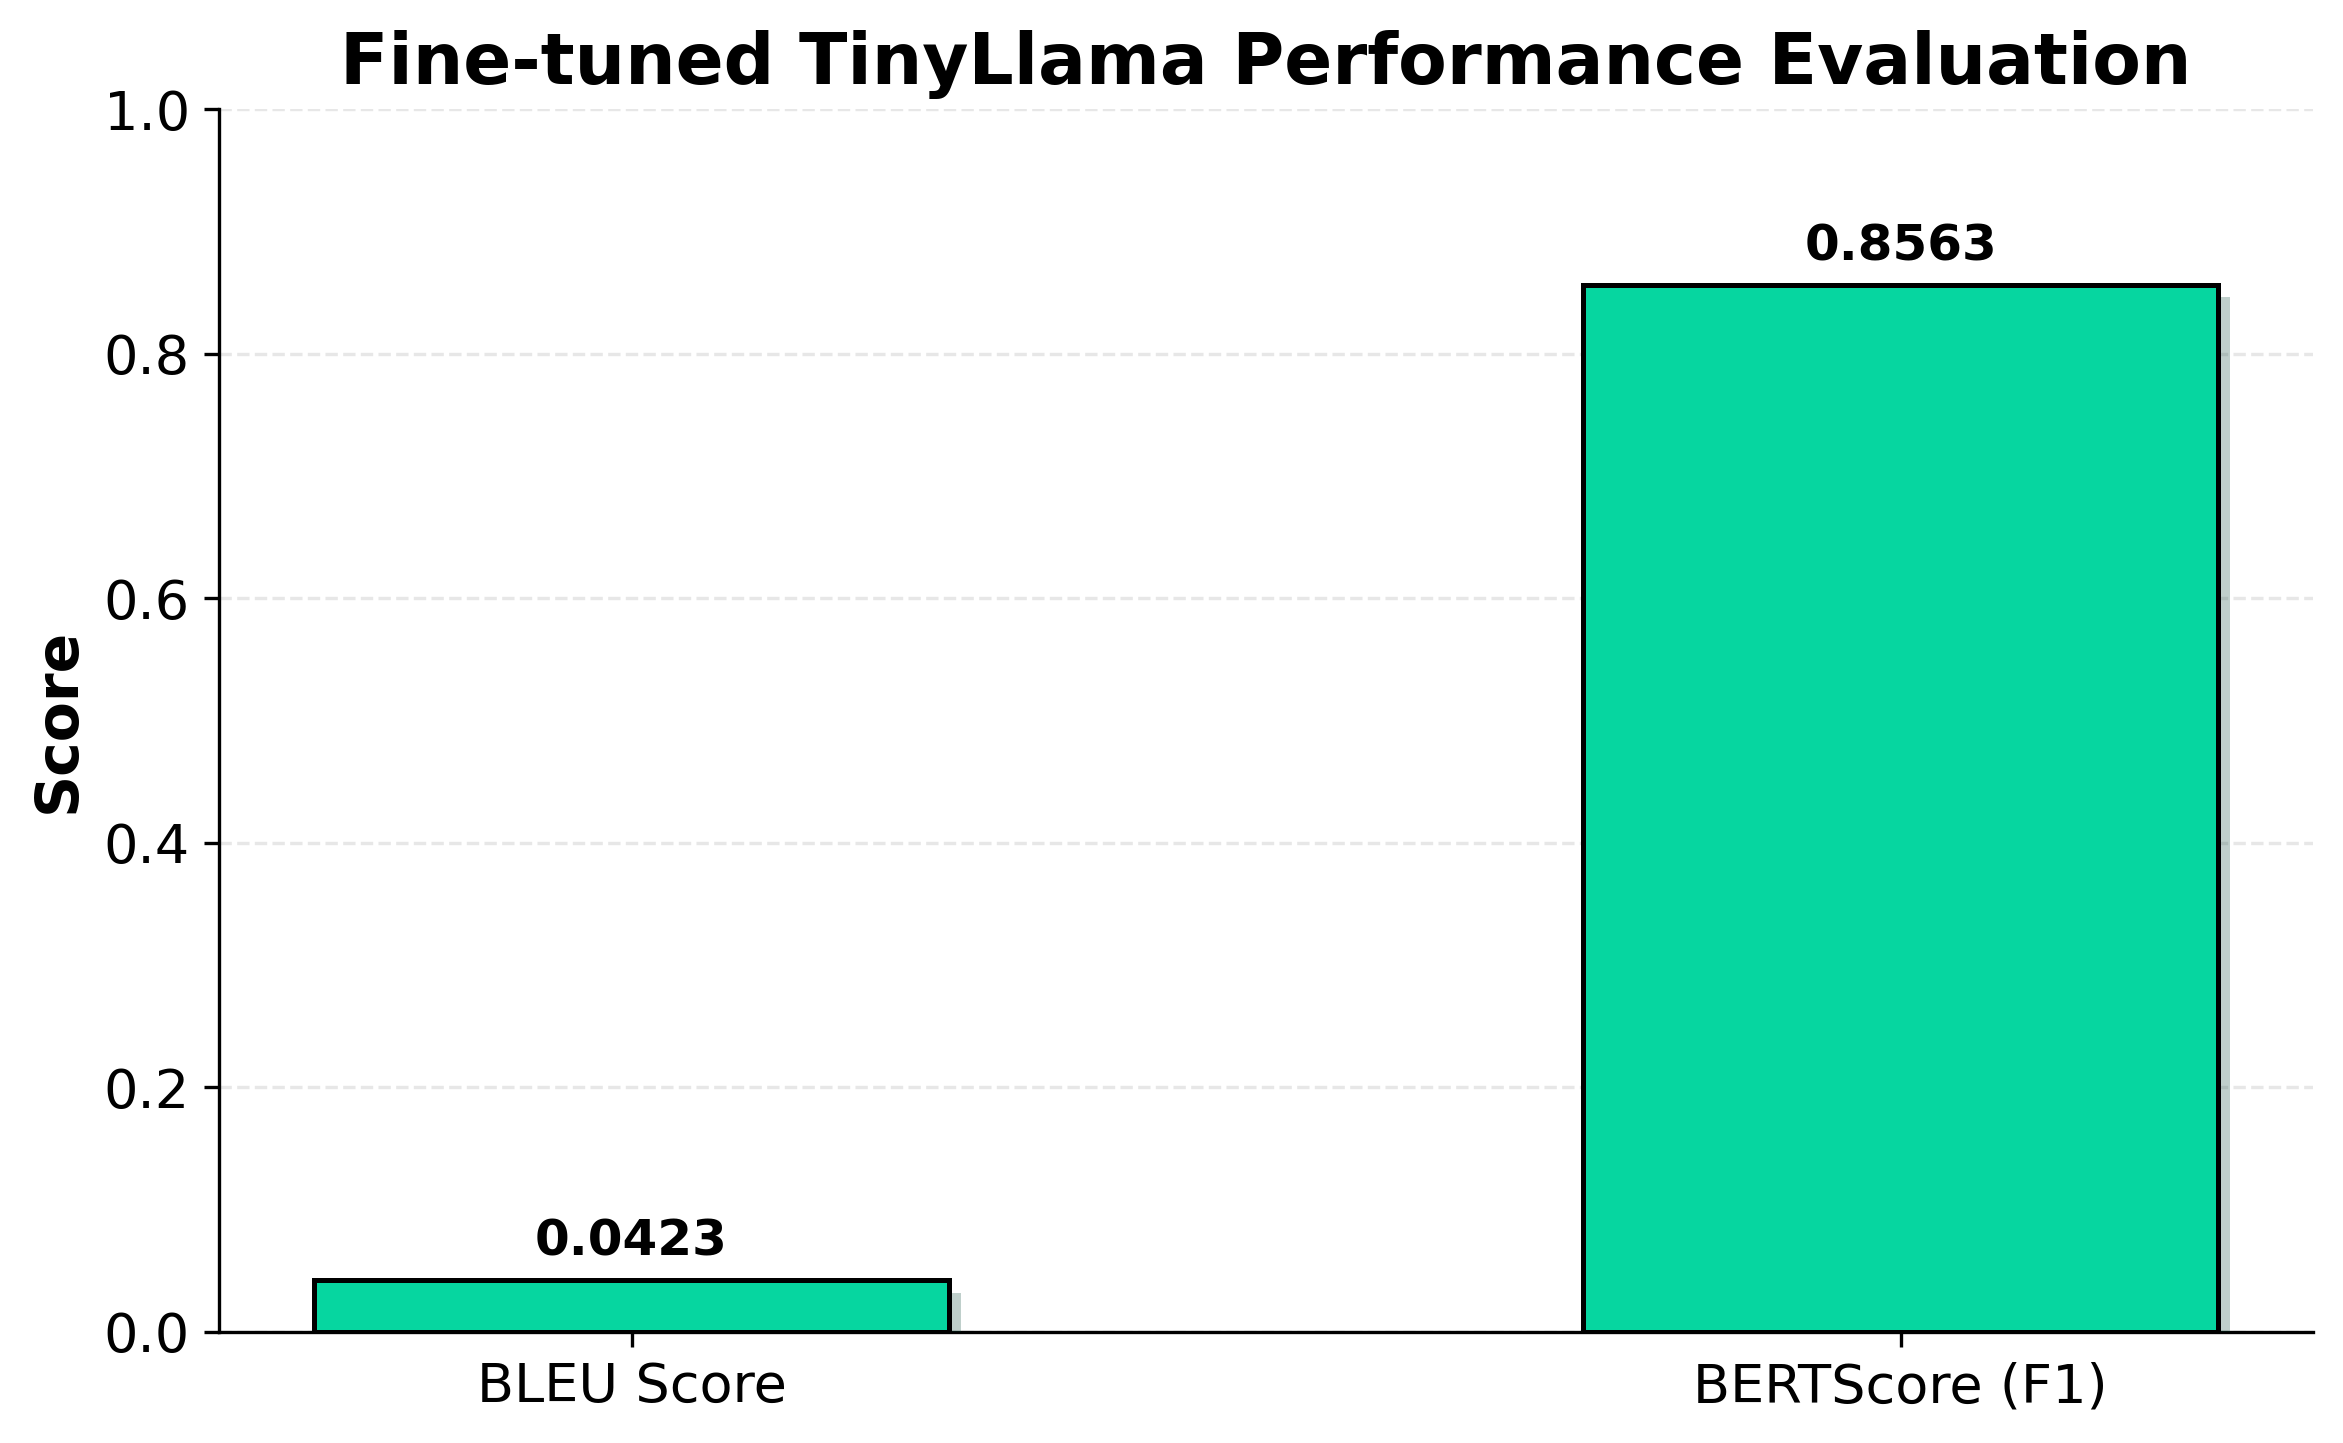

In [108]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Your actual evaluation scores
metrics = ["BLEU Score", "BERTScore (F1)"]
scores = [0.0423, 0.8563]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13
})

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

color = "#06D6A0"

bars = ax.bar(
    metrics,
    scores,
    width=0.5,
    color=color,
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

# Shadow
for b in bars:
    b.set_path_effects([
        pe.SimplePatchShadow(offset=(3, -3), alpha=0.25),
        pe.Normal()
    ])

# Value labels
for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        h + 0.02,
        f"{h:.4f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_ylim(0, 1.0)
ax.set_ylabel("Score", fontsize=14, fontweight="bold")
ax.set_title(
    "Fine-tuned TinyLlama Performance Evaluation",
    fontsize=17,
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("FineTuned_Model_Performance.png", dpi=400)
plt.show()

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
BERT Precision, Recall, and F1 Score
</h2>
</div>

In [114]:
from evaluate import load

# Load BERTScore metric
bertscore = load("bertscore")

# Calculate scores for all samples
bert_result = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

# All individual F1 scores
bert_f1_scores = bert_result["f1"]

# Check number of samples
print("Total BERTScore samples:", len(bert_f1_scores))

# First 10 scores
print("\nFirst 10 BERT F1 scores:")
print(bert_f1_scores[:10])

# Average score
avg_f1 = sum(bert_f1_scores) / len(bert_f1_scores)

print("\nAverage BERTScore F1:", avg_f1)

# Also get Precision and Recall
avg_precision = sum(bert_result["precision"]) / len(bert_result["precision"])
avg_recall = sum(bert_result["recall"]) / len(bert_result["recall"])

print("Average BERT Precision:", avg_precision)
print("Average BERT Recall:", avg_recall)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total BERTScore samples: 500

First 10 BERT F1 scores:
[0.842620849609375, 0.8844438791275024, 0.8860441446304321, 0.8681749105453491, 0.8221530914306641, 0.824286937713623, 0.88883376121521, 0.8838553428649902, 0.8595976233482361, 0.8925526142120361]

Average BERTScore F1: 0.8563184727430344
Average BERT Precision: 0.8478054621219635
Average BERT Recall: 0.8660713551044464


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Evaluation Samples for Fine-tuned TinyLlama Model: 500

First 10 BERT F1 scores:
[0.842620849609375, 0.8844438791275024, 0.8860441446304321, 0.8681749105453491, 0.8221530914306641, 0.824286937713623, 0.88883376121521, 0.8838553428649902, 0.8595976233482361, 0.8925526142120361]

Average BERT Precision: 0.8478054621219635
Average BERT Recall: 0.8660713551044464
Average BERTScore F1: 0.8563184727430344


/tmp/ipykernel_58/249618101.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


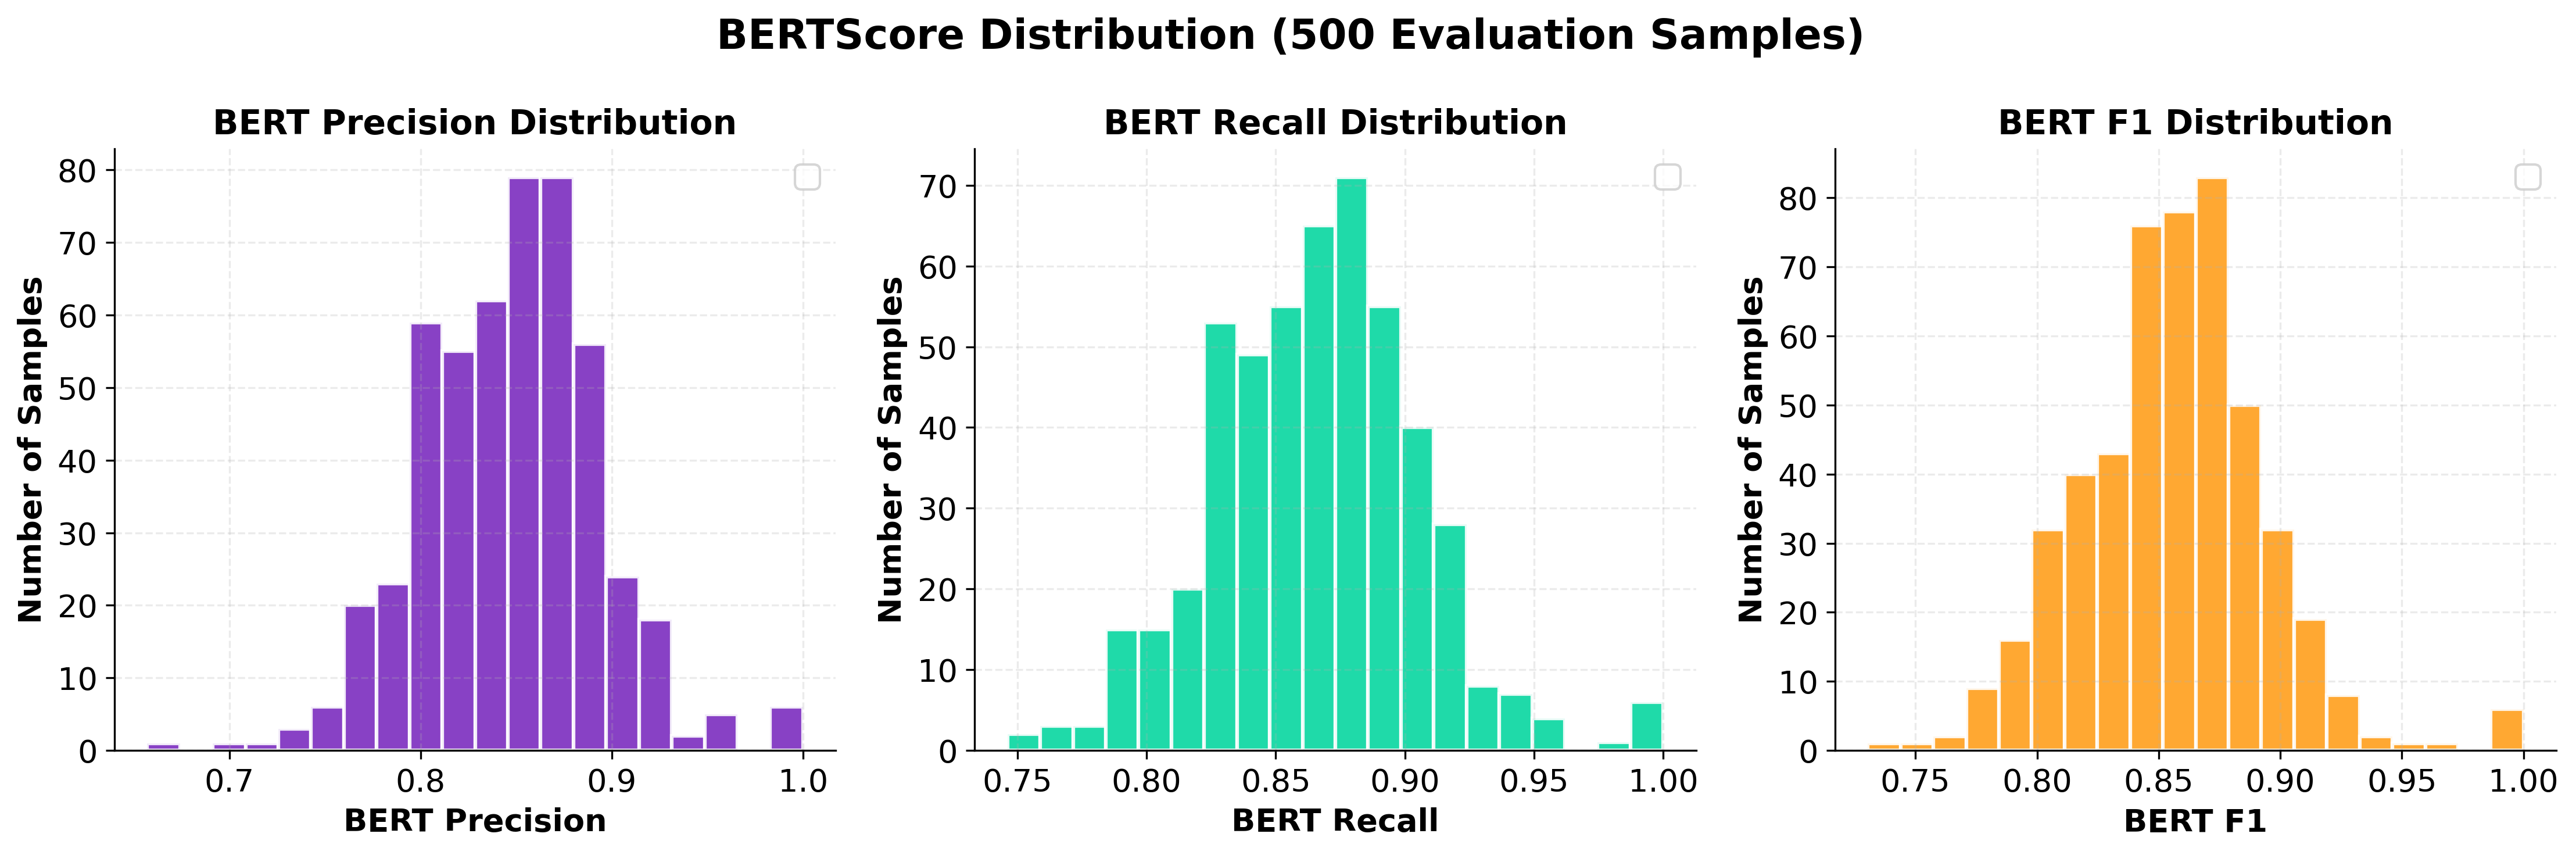

In [120]:
# BERTScore Evaluation + Precision Recall F1 Distribution
from evaluate import load
import matplotlib.pyplot as plt

bertscore = load("bertscore")

bert_result = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

bert_f1_scores = bert_result["f1"]
bert_precision_scores = bert_result["precision"]
bert_recall_scores = bert_result["recall"]

print("Total Evaluation Samples for Fine-tuned TinyLlama Model:", len(bert_f1_scores))

print("\nFirst 10 BERT F1 scores:")
print(bert_f1_scores[:10])

mean_precision = sum(bert_precision_scores)/len(bert_precision_scores)
mean_recall = sum(bert_recall_scores)/len(bert_recall_scores)
mean_f1 = sum(bert_f1_scores)/len(bert_f1_scores)

print("\nAverage BERT Precision:", mean_precision)
print("Average BERT Recall:", mean_recall)
print("Average BERTScore F1:", mean_f1)

fig, axes = plt.subplots(1,3,figsize=(15,5),dpi=300)

colors=["#7B2CBF","#06D6A0","#FF9F1C"]

for ax,scores,mean,title,color in zip(
    axes,
    [bert_precision_scores,bert_recall_scores,bert_f1_scores],
    [mean_precision,mean_recall,mean_f1],
    ["BERT Precision","BERT Recall","BERT F1"],
    colors
):
    ax.hist(scores,bins=20,color=color,edgecolor="white",linewidth=1.5,alpha=0.9)
    # ax.axvline(mean,color="black",linestyle="--",linewidth=2,label=f"Mean={mean:.4f}")
    ax.set_xlabel(title,fontweight="bold")
    ax.set_ylabel("Number of Samples",fontweight="bold")
    ax.set_title(title+" Distribution",fontsize=14,fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.25,linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"BERTScore Distribution ({len(bert_f1_scores)} Evaluation Samples)",fontsize=17,fontweight="bold")
plt.tight_layout()

plt.savefig("BERTScore_Attractive_Distribution.png",dpi=400,bbox_inches="tight")
plt.show()

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Evaluation Samples for Fine-tuned TinyLlama Model: 500

First 10 BERT F1 scores:
[0.842620849609375, 0.8844438791275024, 0.8860441446304321, 0.8681749105453491, 0.8221530914306641, 0.824286937713623, 0.88883376121521, 0.8838553428649902, 0.8595976233482361, 0.8925526142120361]

Average BERT Precision: 0.8478054621219635
Average BERT Recall: 0.8660713551044464
Average BERTScore F1: 0.8563184727430344


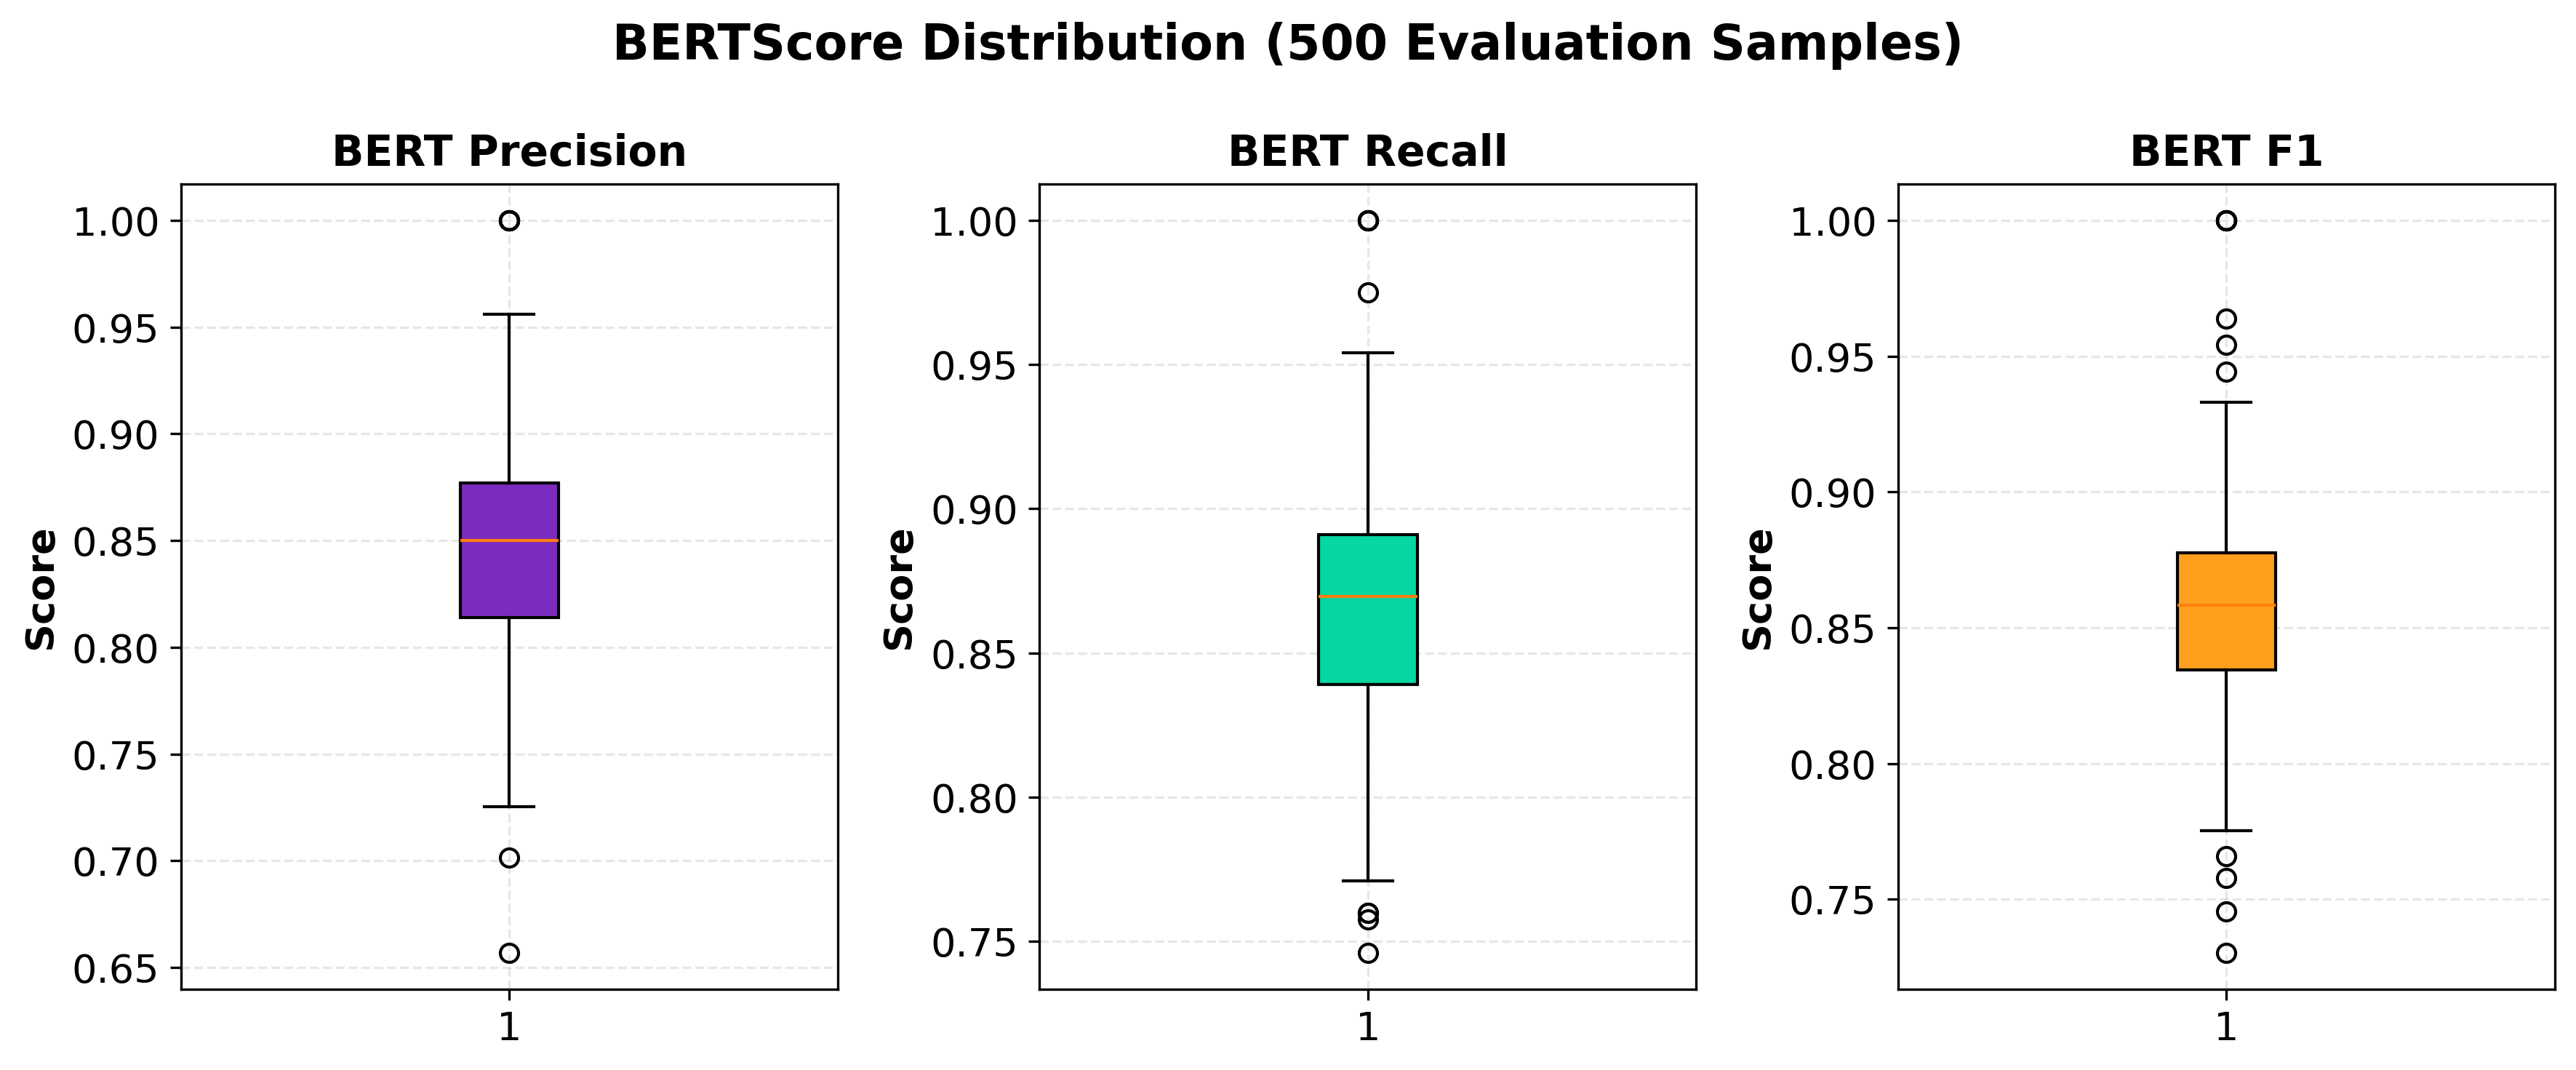

In [121]:
# BERTScore Evaluation + Precision Recall F1 Box Plot

from evaluate import load
import matplotlib.pyplot as plt

# Calculate BERTScore for all samples
bertscore = load("bertscore")

bert_result = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

# Extract all individual scores
bert_f1_scores = bert_result["f1"]
bert_precision_scores = bert_result["precision"]
bert_recall_scores = bert_result["recall"]

print("Total Evaluation Samples for Fine-tuned TinyLlama Model:", len(bert_f1_scores))

# Show first 10 individual F1 scores
print("\nFirst 10 BERT F1 scores:")
print(bert_f1_scores[:10])

# Average BERTScore
mean_precision = sum(bert_precision_scores) / len(bert_precision_scores)
mean_recall = sum(bert_recall_scores) / len(bert_recall_scores)
mean_f1 = sum(bert_f1_scores) / len(bert_f1_scores)

print("\nAverage BERT Precision:", mean_precision)
print("Average BERT Recall:", mean_recall)
print("Average BERTScore F1:", mean_f1)


# Box Plot: Precision Recall F1 Distribution

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12,5),
    dpi=300
)

scores = [
    bert_precision_scores,
    bert_recall_scores,
    bert_f1_scores
]

titles = [
    "BERT Precision",
    "BERT Recall",
    "BERT F1"
]

colors = [
    "#7B2CBF",
    "#06D6A0",
    "#FF9F1C"
]


for ax, score, title, color in zip(axes, scores, titles, colors):

    box = ax.boxplot(
        score,
        patch_artist=True
    )

    for patch in box["boxes"]:
        patch.set_facecolor(color)

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Score",
        fontweight="bold"
    )

    ax.grid(
        alpha=0.3,
        linestyle="--"
    )


plt.suptitle(
    f"BERTScore Distribution ({len(bert_f1_scores)} Evaluation Samples)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "BERTScore_Precision_Recall_F1_BoxPlot.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [122]:
plt.savefig(
    "BERTScore_Precision_Recall_F1_BoxPlot.png",
    dpi=400,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>